In [1]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\angel\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sqlalchemy import create_engine
import urllib

# 1. Conectamos con tu "Única Fuente de la Verdad"
server = 'DESKTOP-08BV2N8'
database = 'Betting_Project'
parametros = urllib.parse.quote_plus(f"DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;")
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={parametros}")

# 2. Hacemos la consulta SQL para traer toda la historia
query = "SELECT * FROM Premier_Historico"

print("⏳ Extrayendo datos históricos para el modelo...")
df_ml = pd.read_sql(query, engine)

# 3. Verificamos qué le vamos a dar de comer al algoritmo
print(f"🤖 ¡Datos cargados! Tenemos {df_ml.shape[0]} partidos listos para entrenar.")
df_ml

⏳ Extrayendo datos históricos para el modelo...
🤖 ¡Datos cargados! Tenemos 380 partidos listos para entrenar.


,Fecha,Equipo_Local,Equipo_Visitante,Goles_Local (FTHG),Goles_Visitante (FTAG),Resultado_Final (FTR),Cuota_Local (B365H),Cuota_Empate (B365D),Cuota_Visitante (B365A)
0,2023-08-11,Burnley,Man City,0,3,A,8.00,5.50,1.33
1,2023-08-12,Arsenal,Nott'm Forest,2,1,H,1.18,7.00,15.00
2,2023-08-12,Bournemouth,West Ham,1,1,D,2.70,3.40,2.55
3,2023-08-12,Brighton,Luton,4,1,H,1.33,5.50,9.00
4,2023-08-12,Everton,Fulham,0,1,A,2.20,3.40,3.30
...,...,...,...,...,...,...,...,...,...
375,2024-05-19,Crystal Palace,Aston Villa,5,0,H,1.85,4.33,3.60
376,2024-05-19,Liverpool,Wolves,2,0,H,1.17,8.00,15.00
377,2024-05-19,Luton,Fulham,2,4,A,2.90,3.90,2.20
378,2024-05-19,Man City,West Ham,3,1,H,1.08,12.00,21.00


In [3]:
from sklearn.model_selection import train_test_split

# 1. Limpieza preventiva: Eliminamos filas que por algún motivo no tengan cuotas
df_ml = df_ml.dropna(subset=['Cuota_Local (B365H)', 'Cuota_Empate (B365D)', 'Cuota_Visitante (B365A)', 'Resultado_Final (FTR)'])

# 2. Definimos la 'X' (Las pistas/Features)
X = df_ml[['Cuota_Local (B365H)', 'Cuota_Empate (B365D)', 'Cuota_Visitante (B365A)']]

# 3. Definimos la 'y' (El objetivo/Target que queremos predecir: H, D, A)
y = df_ml['Resultado_Final (FTR)']

# 4. Dividimos en Entrenamiento (Train) y Prueba (Test)
# test_size=0.2 significa que guardamos el 20% para el examen final
# random_state=42 es la "semilla" para que a los dos nos dé el mismo resultado exacto
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("📊 División completada con éxito:")
print(f"📚 Datos para que la IA estudie (Train): {X_train.shape[0]} partidos.")
print(f"📝 Datos para el examen sorpresa (Test): {X_test.shape[0]} partidos.")

📊 División completada con éxito:
📚 Datos para que la IA estudie (Train): 304 partidos.
📝 Datos para el examen sorpresa (Test): 76 partidos.


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Invocamos al "Gladiador": El Bosque Aleatorio con 100 árboles
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. FASE DE ENTRENAMIENTO (El modelo estudia el 80% de los datos)
print("🧠 Entrenando al algoritmo con el historial de cuotas...")
modelo_rf.fit(X_train, y_train)

# 3. FASE DE PREDICCIÓN (Le pasamos el 20% del examen sin las respuestas)
predicciones = modelo_rf.predict(X_test)

# 4. EVALUACIÓN (Comparamos sus predicciones con la realidad)
precision = accuracy_score(y_test, predicciones)

print(f"✅ ¡Examen terminado!\n")
print(f"🎯 Precisión Global (Accuracy): {precision * 100:.2f}%\n")

print("📊 Reporte Detallado por Tipo de Resultado:")
# Cero advertencias: zero_division=0 evita alertas si el modelo no adivina un resultado específico
print(classification_report(y_test, predicciones, zero_division=0))

🧠 Entrenando al algoritmo con el historial de cuotas...
✅ ¡Examen terminado!

🎯 Precisión Global (Accuracy): 50.00%

📊 Reporte Detallado por Tipo de Resultado:
              precision    recall  f1-score   support

           A       0.52      0.54      0.53        26
           D       0.30      0.16      0.21        19
           H       0.54      0.68      0.60        31

    accuracy                           0.50        76
   macro avg       0.45      0.46      0.45        76
weighted avg       0.47      0.50      0.48        76



In [5]:
# 1. Vital: Ordenar los datos cronológicamente (de más antiguo a más reciente)
df_ml = df_ml.sort_values(by='Fecha').reset_index(drop=True)

# 2. Creamos la función que "viaja en el tiempo"
def calcular_puntos_ultimos_3(equipo, fecha_actual, df):
    # Filtramos: Partidos de este equipo que ocurrieron ANTES de la fecha actual
    filtro_pasado = df[
        ((df['Equipo_Local'] == equipo) | (df['Equipo_Visitante'] == equipo)) & 
        (df['Fecha'] < fecha_actual)
    ]
    
    # Tomamos solo los últimos 3 partidos de ese historial
    ultimos_3 = filtro_pasado.tail(3)
    
    puntos = 0
    # Evaluamos cada uno de esos 3 partidos
    for index, row in ultimos_3.iterrows():
        if row['Equipo_Local'] == equipo:
            if row['Resultado_Final (FTR)'] == 'H': puntos += 3
            elif row['Resultado_Final (FTR)'] == 'D': puntos += 1
        else: # Si el equipo jugó como visitante
            if row['Resultado_Final (FTR)'] == 'A': puntos += 3
            elif row['Resultado_Final (FTR)'] == 'D': puntos += 1
            
    return puntos

# 3. Aplicamos la función a todo el dataset
print("⏳ Calculando el estado de forma de los equipos... Esto tomará unos segundos.")

# Calculamos los puntos recientes para el equipo que hoy juega de Local
df_ml['Puntos_Local_Ultimos_3'] = df_ml.apply(
    lambda row: calcular_puntos_ultimos_3(row['Equipo_Local'], row['Fecha'], df_ml), axis=1
)

# Calculamos los puntos recientes para el equipo que hoy juega de Visitante
df_ml['Puntos_Visit_Ultimos_3'] = df_ml.apply(
    lambda row: calcular_puntos_ultimos_3(row['Equipo_Visitante'], row['Fecha'], df_ml), axis=1
)

print("✅ ¡Nuevas variables predictoras creadas con éxito!")

# 4. Verificamos el resultado viendo las últimas 5 filas
df_ml[['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Puntos_Local_Ultimos_3', 'Puntos_Visit_Ultimos_3']].tail()

⏳ Calculando el estado de forma de los equipos... Esto tomará unos segundos.
✅ ¡Nuevas variables predictoras creadas con éxito!


,Fecha,Equipo_Local,Equipo_Visitante,Puntos_Local_Ultimos_3,Puntos_Visit_Ultimos_3
375,2024-05-19,Brighton,Man United,4,3
376,2024-05-19,Brentford,Newcastle,4,4
377,2024-05-19,Arsenal,Everton,9,7
378,2024-05-19,Burnley,Nott'm Forest,1,3
379,2024-05-19,Sheffield United,Tottenham,0,3


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Redefinimos la 'X' incluyendo las nuevas columnas de racha

df_ml = df_ml.dropna() 

X_nuevo = df_ml[['Cuota_Local (B365H)', 'Cuota_Empate (B365D)', 'Cuota_Visitante (B365A)', 
                 'Puntos_Local_Ultimos_3', 'Puntos_Visit_Ultimos_3']]

# La 'y' sigue siendo el resultado final
y_nuevo = df_ml['Resultado_Final (FTR)']

# 2. Volvemos a dividir los datos (mantenemos el 20% para el examen)
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_nuevo, y_nuevo, test_size=0.2, random_state=42)

# 3. Invocamos al modelo de nuevo
modelo_rf_v2 = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. Lo entrenamos con la nueva inteligencia
print("🧠 Entrenando al modelo v2.0 con historial de racha de puntos...")
modelo_rf_v2.fit(X_train_n, y_train_n)

# 5. Predicción y Evaluación
pred_v2 = modelo_rf_v2.predict(X_test_n)
precision_v2 = accuracy_score(y_test_n, pred_v2)

print(f"✅ ¡Examen v2.0 terminado!\n")
print(f"🎯 Nueva Precisión Global (Accuracy): {precision_v2 * 100:.2f}%\n")
print("📊 Nuevo Reporte Detallado:")
print(classification_report(y_test_n, pred_v2, zero_division=0))

🧠 Entrenando al modelo v2.0 con historial de racha de puntos...
✅ ¡Examen v2.0 terminado!

🎯 Nueva Precisión Global (Accuracy): 52.63%

📊 Nuevo Reporte Detallado:
              precision    recall  f1-score   support

           A       0.58      0.62      0.60        29
           D       0.11      0.06      0.08        16
           H       0.58      0.68      0.63        31

    accuracy                           0.53        76
   macro avg       0.43      0.45      0.44        76
weighted avg       0.48      0.53      0.50        76



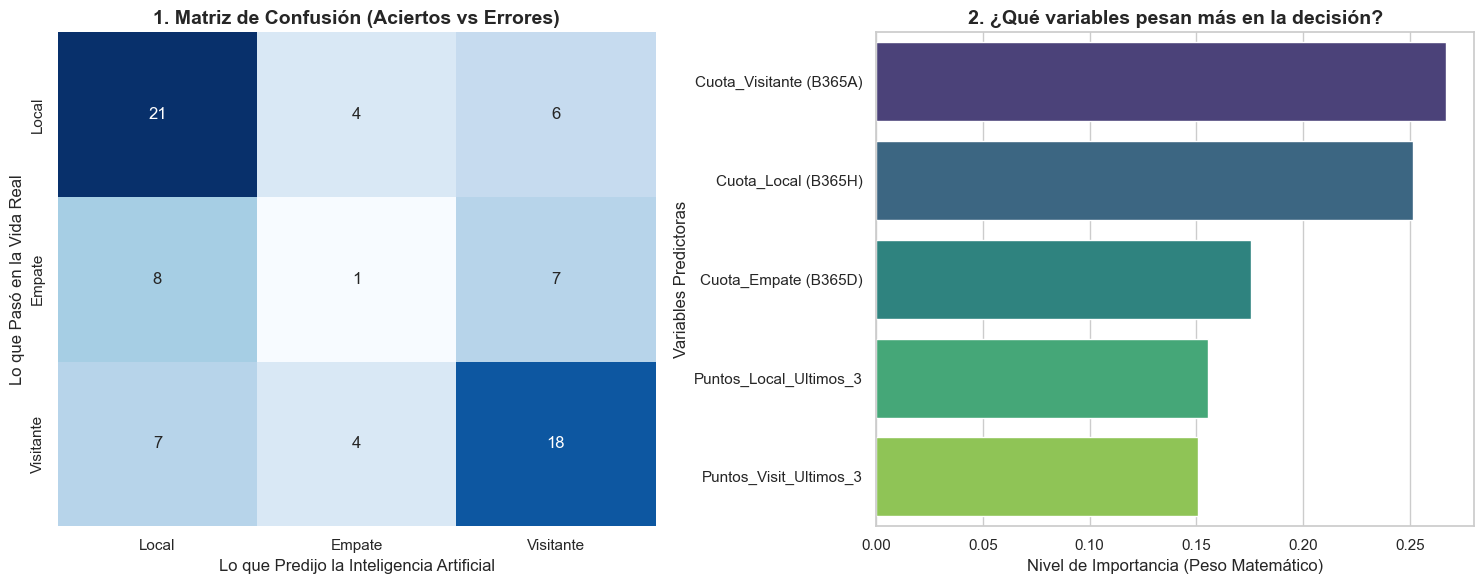

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Configuración general para que se vea elegante
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- GRÁFICO 1: La Matriz de Confusión ---
# Calculamos la matriz con el orden lógico: Local, Empate, Visitante
cm = confusion_matrix(y_test_n, pred_v2, labels=['H', 'D', 'A'])

# Dibujamos un "Heatmap" (Mapa de calor)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Local', 'Empate', 'Visitante'],
            yticklabels=['Local', 'Empate', 'Visitante'],
            cbar=False)

axes[0].set_title('1. Matriz de Confusión (Aciertos vs Errores)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lo que Predijo la Inteligencia Artificial', fontsize=12)
axes[0].set_ylabel('Lo que Pasó en la Vida Real', fontsize=12)

# --- GRÁFICO 2: Importancia de las Variables (Feature Importance) ---
# Extraemos el "peso" que el modelo le dio a cada columna para tomar su decisión
importancias = modelo_rf_v2.feature_importances_
columnas = X_nuevo.columns

# Ordenamos de mayor a menor importancia
indices = np.argsort(importancias)[::-1]

# Dibujamos un gráfico de barras horizontal
sns.barplot(x=importancias[indices], y=columnas[indices], ax=axes[1], palette='viridis', hue=columnas[indices], legend=False)

axes[1].set_title('2. ¿Qué variables pesan más en la decisión?', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nivel de Importancia (Peso Matemático)', fontsize=12)
axes[1].set_ylabel('Variables Predictoras', fontsize=12)

# Ajustamos el diseño y mostramos
plt.tight_layout()
plt.show()

In [9]:
 #Las Barras de Colores (Feature Importance)
#"No es una caja negra mágica; aquí sabemos cómo piensa la máquina. Este gráfico de barras muestra qué datos influyen más para adivinar el resultado."

In [10]:
#El Simulador Financiero (Backtesting)

# 1. Unimos las pistas (cuotas), la realidad y lo que predijo la IA en una sola tabla
resultados = X_test_n.copy()
resultados['Realidad'] = y_test_n
resultados['Prediccion_IA'] = pred_v2

# 2. Definimos la billetera (Tu capital)
inversion_por_apuesta = 10000
inversion_total = len(resultados) * inversion_por_apuesta
ganancia_neta = 0

# 3. El algoritmo simula ir a la casa de apuestas partido por partido
for index, row in resultados.iterrows():
    prediccion = row['Prediccion_IA']
    realidad = row['Realidad']
    
    # Si la IA acertó, vamos a cobrar al cajero
    if prediccion == realidad:
        if prediccion == 'H':
            cuota = row['Cuota_Local (B365H)']
        elif prediccion == 'D':
            cuota = row['Cuota_Empate (B365D)']
        elif prediccion == 'A':
            cuota = row['Cuota_Visitante (B365A)']
            
        # Fórmula de ganancia: (Inversión * Cuota) - Lo que invertimos inicialmente
        ganancia_neta += (inversion_por_apuesta * cuota) - inversion_por_apuesta
    
    # Si la IA falló, perdemos el billete
    else:
        ganancia_neta -= inversion_por_apuesta

# 4. Calculamos el Retorno de Inversión (ROI)
roi = (ganancia_neta / inversion_total) * 100

print(f"🏦 --- REPORTE FINANCIERO DEL ALGORITMO v2.0 --- 🏦\n")
print(f"📊 Partidos apostados: {len(resultados)}")
print(f"💸 Inversión total arriesgada: ${inversion_total:,.0f} COP")
print(f"💵 Ganancia/Pérdida Neta: ${ganancia_neta:,.0f} COP")

# Le damos color al resultado para que se vea como dashboard
if ganancia_neta > 0:
    print(f"✅ ESTADO: RENTABLE | ROI: {roi:.2f}% de pura ganancia.")
else:
    print(f"❌ ESTADO: EN PÉRDIDA | ROI: {roi:.2f}%. Aún gana la casa de apuestas.")

🏦 --- REPORTE FINANCIERO DEL ALGORITMO v2.0 --- 🏦

📊 Partidos apostados: 76
💸 Inversión total arriesgada: $760,000 COP
💵 Ganancia/Pérdida Neta: $-53,900 COP
❌ ESTADO: EN PÉRDIDA | ROI: -7.09%. Aún gana la casa de apuestas.


In [11]:
#Extracion de goles
# 1. Creamos la función para calcular Goles a Favor (GF) y Goles en Contra (GC)
def calcular_goles_ultimos_3(equipo, fecha_actual, df):
    # Buscamos el historial del equipo antes del partido actual
    filtro_pasado = df[
        ((df['Equipo_Local'] == equipo) | (df['Equipo_Visitante'] == equipo)) & 
        (df['Fecha'] < fecha_actual)
    ]
    
    ultimos_3 = filtro_pasado.tail(3)
    
    goles_favor = 0
    goles_contra = 0
    
    # Revisamos cada partido para sumar los goles correctamente
    for index, row in ultimos_3.iterrows():
        if row['Equipo_Local'] == equipo: # Si jugó de local
            goles_favor += row['Goles_Local (FTHG)']
            goles_contra += row['Goles_Visitante (FTAG)']
        else: # Si jugó de visitante
            goles_favor += row['Goles_Visitante (FTAG)']
            goles_contra += row['Goles_Local (FTHG)']
            
    # Devolvemos ambos números a la vez
    return pd.Series([goles_favor, goles_contra])

# 2. Aplicamos la función a nuestra base de datos
print("⏳ Analizando videos tácticos y contando goles... (Esto tomará unos segundos)")

# Calculamos para los Locales
df_ml[['GF_Local_Ultimos_3', 'GC_Local_Ultimos_3']] = df_ml.apply(
    lambda row: calcular_goles_ultimos_3(row['Equipo_Local'], row['Fecha'], df_ml), axis=1
)

# Calculamos para los Visitantes
df_ml[['GF_Visit_Ultimos_3', 'GC_Visit_Ultimos_3']] = df_ml.apply(
    lambda row: calcular_goles_ultimos_3(row['Equipo_Visitante'], row['Fecha'], df_ml), axis=1
)

print("✅ ¡Poder Ofensivo y Defensivo calculados con éxito!")

# 3. Revisamos que las columnas se hayan creado bien
df_ml[['Fecha', 'Equipo_Local', 'GF_Local_Ultimos_3', 'GC_Local_Ultimos_3', 'Equipo_Visitante', 'GF_Visit_Ultimos_3', 'GC_Visit_Ultimos_3']].tail()

⏳ Analizando videos tácticos y contando goles... (Esto tomará unos segundos)
✅ ¡Poder Ofensivo y Defensivo calculados con éxito!


,Fecha,Equipo_Local,GF_Local_Ultimos_3,GC_Local_Ultimos_3,Equipo_Visitante,GF_Visit_Ultimos_3,GC_Visit_Ultimos_3
375,2024-05-19,Brighton,3,3,Man United,3,7
376,2024-05-19,Brentford,2,2,Newcastle,7,5
377,2024-05-19,Arsenal,7,2,Everton,3,1
378,2024-05-19,Burnley,3,7,Nott'm Forest,5,6
379,2024-05-19,Sheffield United,2,9,Tottenham,4,7


In [12]:
# 1. Redefinimos la 'X' con el arsenal completo (Cuotas + Puntos + Goles)
# Limpieza preventiva en caso de que los primeros 3 partidos de la liga tengan datos nulos
df_ml = df_ml.dropna() 

X_v3 = df_ml[['Cuota_Local (B365H)', 'Cuota_Empate (B365D)', 'Cuota_Visitante (B365A)', 
              'Puntos_Local_Ultimos_3', 'Puntos_Visit_Ultimos_3',
              'GF_Local_Ultimos_3', 'GC_Local_Ultimos_3',
              'GF_Visit_Ultimos_3', 'GC_Visit_Ultimos_3']]

y_v3 = df_ml['Resultado_Final (FTR)']

# 2. Dividimos los datos (80% estudio, 20% examen)
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(X_v3, y_v3, test_size=0.2, random_state=42)

# 3. Entrenamos el "Cerebro" v3.0
print("🧠 Entrenando IA con Cuotas + Racha de Puntos + Poder Ofensivo/Defensivo...\n")
modelo_rf_v3 = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf_v3.fit(X_train_v3, y_train_v3)

# 4. Evaluación de Precisión
pred_v3 = modelo_rf_v3.predict(X_test_v3)
precision_v3 = accuracy_score(y_test_v3, pred_v3)

print(f"🎯 Precisión Global v3.0 (Accuracy): {precision_v3 * 100:.2f}%\n")

# --- SIMULADOR FINANCIERO INTEGRADO ---
resultados_v3 = X_test_v3.copy()
resultados_v3['Realidad'] = y_test_v3
resultados_v3['Prediccion_IA'] = pred_v3

ganancia_neta_v3 = 0
inversion_por_apuesta = 10000
inversion_total_v3 = len(resultados_v3) * inversion_por_apuesta

for index, row in resultados_v3.iterrows():
    pred = row['Prediccion_IA']
    real = row['Realidad']
    
    if pred == real:
        if pred == 'H': cuota = row['Cuota_Local (B365H)']
        elif pred == 'D': cuota = row['Cuota_Empate (B365D)']
        elif pred == 'A': cuota = row['Cuota_Visitante (B365A)']
        
        ganancia_neta_v3 += (inversion_por_apuesta * cuota) - inversion_por_apuesta
    else:
        ganancia_neta_v3 -= inversion_por_apuesta

roi_v3 = (ganancia_neta_v3 / inversion_total_v3) * 100

print(f"🏦 --- REPORTE FINANCIERO v3.0 --- 🏦")
print(f"📊 Partidos apostados: {len(resultados_v3)}")
print(f"💸 Inversión total arriesgada: ${inversion_total_v3:,.0f} COP")
print(f"💵 Ganancia/Pérdida Neta: ${ganancia_neta_v3:,.0f} COP")

if ganancia_neta_v3 > 0:
    print(f"✅ ESTADO: RENTABLE | ROI: {roi_v3:.2f}% de pura ganancia. ¡Rompiste el sistema!")
else:
    print(f"❌ ESTADO: EN PÉRDIDA | ROI: {roi_v3:.2f}%. Aún gana la casa de apuestas.")

🧠 Entrenando IA con Cuotas + Racha de Puntos + Poder Ofensivo/Defensivo...

🎯 Precisión Global v3.0 (Accuracy): 56.58%

🏦 --- REPORTE FINANCIERO v3.0 --- 🏦
📊 Partidos apostados: 76
💸 Inversión total arriesgada: $760,000 COP
💵 Ganancia/Pérdida Neta: $-29,700 COP
❌ ESTADO: EN PÉRDIDA | ROI: -3.91%. Aún gana la casa de apuestas.


In [13]:
#El Filtro de Confianza (predict_proba)
#Le diremos al simulador: "Angelo autoriza soltar los 10,000 COP ÚNICAMENTE si estás más del 55% seguro de tu predicción. Si estás dudando, guarda la plata en el bolsillo".
# 1. En lugar de .predict(), usamos .predict_proba() para ver los porcentajes de la IA
probabilidades = modelo_rf_v3.predict_proba(X_test_v3)

ganancia_neta_inteligente = 0
partidos_apostados = 0
inversion_por_apuesta = 10000

# 2. Definimos nuestra regla de oro (El Umbral de Confianza)
umbral_seguridad = 0.55 # Solo apostamos si la IA está >= 55% segura

print("🤖 Analizando la cartelera con lupa financiera...\n")

# Extraemos las clases que el modelo conoce (A, D, H)
clases_modelo = modelo_rf_v3.classes_

for i in range(len(resultados_v3)):
    fila = resultados_v3.iloc[i]
    realidad = fila['Realidad']
    
    # Porcentajes internos de la IA para este partido específico
    probs_partido = probabilidades[i]
    
    # Encontramos la opción con el porcentaje más alto
    max_prob = max(probs_partido)
    indice_max_prob = list(probs_partido).index(max_prob)
    prediccion_ia = clases_modelo[indice_max_prob]
    
    # 3. LA REGLA DE NEGOCIO: ¿Apostamos o pasamos?
    if max_prob >= umbral_seguridad:
        partidos_apostados += 1
        
        # Verificamos si acertó
        if prediccion_ia == realidad:
            if prediccion_ia == 'H': cuota = fila['Cuota_Local (B365H)']
            elif prediccion_ia == 'D': cuota = fila['Cuota_Empate (B365D)']
            elif prediccion_ia == 'A': cuota = fila['Cuota_Visitante (B365A)']
            
            ganancia_neta_inteligente += (inversion_por_apuesta * cuota) - inversion_por_apuesta
        else:
            # Si falló, perdemos la apuesta
            ganancia_neta_inteligente -= inversion_por_apuesta

# 4. Reporte Final
inversion_total_inteligente = partidos_apostados * inversion_por_apuesta
if inversion_total_inteligente > 0:
    roi_inteligente = (ganancia_neta_inteligente / inversion_total_inteligente) * 100
else:
    roi_inteligente = 0

print(f"🏦 --- REPORTE FINANCIERO CON GESTIÓN DE RIESGO --- 🏦")
print(f"🛑 Partidos descartados por dudas: {len(resultados_v3) - partidos_apostados}")
print(f"✅ Partidos apostados (Alta Confianza): {partidos_apostados}")
print(f"💸 Inversión total arriesgada: ${inversion_total_inteligente:,.0f} COP")
print(f"💵 Ganancia/Pérdida Neta: ${ganancia_neta_inteligente:,.0f} COP")

if ganancia_neta_inteligente > 0:
    print(f"🟢 ESTADO: RENTABLE | ROI: {roi_inteligente:.2f}% ¡HACKEAMOS EL SISTEMA!")
elif ganancia_neta_inteligente == 0 and partidos_apostados == 0:
    print(f"🟡 ESTADO: NEUTRAL | La IA no encontró ninguna apuesta segura mayor al {umbral_seguridad*100}%.")
else:
    print(f"🔴 ESTADO: EN PÉRDIDA | ROI: {roi_inteligente:.2f}%. Falta ajustar el modelo.")

🤖 Analizando la cartelera con lupa financiera...

🏦 --- REPORTE FINANCIERO CON GESTIÓN DE RIESGO --- 🏦
🛑 Partidos descartados por dudas: 23
✅ Partidos apostados (Alta Confianza): 53
💸 Inversión total arriesgada: $530,000 COP
💵 Ganancia/Pérdida Neta: $-66,100 COP
🔴 ESTADO: EN PÉRDIDA | ROI: -12.47%. Falta ajustar el modelo.
